### Feature Extraction

#### Nama : Alexander Ricky
#### NIM 255314035

In [19]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

In [11]:
## Baca data file nba terlampir simpan dengan nama df
nba_df= pd.read_excel("nba_allseason.xlsx")
## Tampilkan isi df
nba_df

,player_name,team_abbreviation,age,player_height,player_weight,college,country,draft_year,draft_round,draft_number,...,pts,reb,ast,net_rating,oreb_pct,dreb_pct,usg_pct,ts_pct,ast_pct,season
0,Randy Livingston,HOU,22,193.04,94.800728,Louisiana State,USA,1996,2,42,...,3.9,1.5,2.4,0.3,0.042,0.071,0.169,0.487,0.248,1996-97
1,Gaylon Nickerson,WAS,28,190.50,86.182480,Northwestern Oklahoma,USA,1994,2,34,...,3.8,1.3,0.3,8.9,0.030,0.111,0.174,0.497,0.043,1996-97
2,George Lynch,VAN,26,203.20,103.418976,North Carolina,USA,1993,1,12,...,8.3,6.4,1.9,-8.2,0.106,0.185,0.175,0.512,0.125,1996-97
3,George McCloud,LAL,30,203.20,102.058200,Florida State,USA,1989,1,7,...,10.2,2.8,1.7,-2.7,0.027,0.111,0.206,0.527,0.125,1996-97
4,George Zidek,DEN,23,213.36,119.748288,UCLA,USA,1995,1,22,...,2.8,1.7,0.3,-14.1,0.102,0.169,0.195,0.500,0.064,1996-97
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12839,Joel Embiid,PHI,29,213.36,127.005760,Kansas,Cameroon,2014,1,3,...,33.1,10.2,4.2,8.8,0.057,0.243,0.370,0.655,0.233,2022-23
12840,John Butler Jr.,POR,20,213.36,86.182480,Florida State,USA,Undrafted,Undrafted,Undrafted,...,2.4,0.9,0.6,-16.1,0.012,0.065,0.102,0.411,0.066,2022-23
12841,John Collins,ATL,25,205.74,102.511792,Wake Forest,USA,2017,1,19,...,13.1,6.5,1.2,-0.2,0.035,0.180,0.168,0.593,0.052,2022-23
12842,Jericho Sims,NYK,24,208.28,113.398000,Texas,USA,2021,2,58,...,3.4,4.7,0.5,-6.7,0.117,0.175,0.074,0.780,0.044,2022-23


### Pemilihan fitur usia dan jumlah poin bertujuan untuk menganalisis masa puncak performa seorang pemain, sekaligus membuktikan secara statistik pola lintasan karier di mana produktivitas mencetak angka akan mencapai titik maksimal pada rentang usia tertentu sebelum akhirnya mengalami penurunan.

In [12]:
features1 = ["age", "pts"]

data = nba_df [features1].copy()
data

,age,pts
0,22,3.9
1,28,3.8
2,26,8.3
3,30,10.2
4,23,2.8
...,...,...
12839,29,33.1
12840,20,2.4
12841,25,13.1
12842,24,3.4


In [13]:
cor = data.corr()
print(cor)

          age       pts
age  1.000000  0.011353
pts  0.011353  1.000000


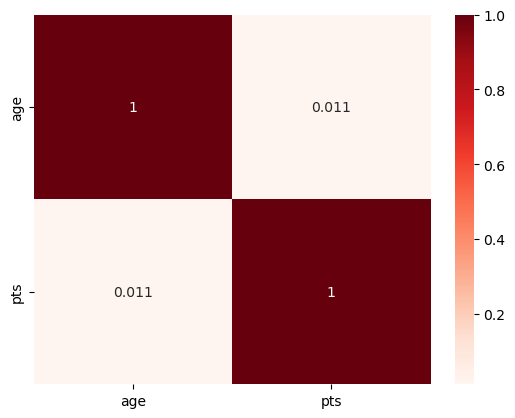

In [14]:
sns.heatmap(cor,annot=True,cmap=plt.cm.Reds)
plt.show()

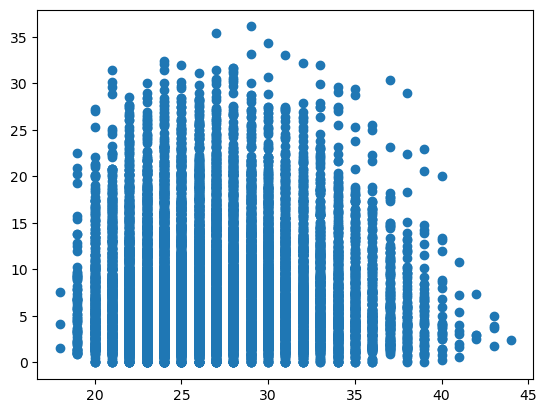

In [15]:
plt.scatter(data.iloc[:,0],data.iloc[:,1])
plt.show()

In [20]:
pca = PCA(n_components=2)
pca_result=pca.fit_transform(data)

In [21]:
#Menampilkan matrix covarian
print('Matrix covarian')
print(pca.get_covariance())

Matrix covarian
[[18.82874935  0.29640095]
 [ 0.29640095 36.19915649]]


In [22]:
print("Eigenvalue : ")
print(pca.explained_variance_)

Eigenvalue : 
[36.20421267 18.82369316]


In [23]:
print("Eigenvector : ")
print(pca.components_)

Eigenvector : 
[[ 0.01705611  0.99985453]
 [ 0.99985453 -0.01705611]]


In [24]:
print("Hasil Transformasi PCA")
print(pca_result)

Hasil Transformasi PCA
[[-4.39800784 -4.97102319]
 [-4.39565662  1.02980962]
 [ 0.06957656 -1.04665194]
 ...
 [ 4.85182221 -2.12837581]
 [-4.86382288 -2.96278607]
 [-1.71075428  5.9847364 ]]


plt.scatter(pca_result[:,0],pca_result[0:,1])
plt.show()

In [26]:
df_pca = pd.DataFrame(pca_result, columns = ['PC1', 'PC2'])

In [27]:
print ("Kolerasi antar Komponen PCA (Age vs Point)")
print (df_pca.corr())

Kolerasi antar Komponen PCA (Age vs Point)
              PC1           PC2
PC1  1.000000e+00 -2.615938e-15
PC2 -2.615938e-15  1.000000e+00


#### Berdasarkan analisis dataset pemain NBA, usia (age) dan rata-rata jumlah poin (pts) memiliki hubungan korelasi linear yang sangat lemah, yaitu hanya sebesar 0,011353. Nilai yang nyaris mendekati nol ini membuktikan bahwa usia tidak secara konstan berbanding lurus dengan peningkatan poin di sepanjang karier seorang pemain. Secara logis, hal ini terjadi karena produktivitas seorang atlet tidak bergerak dalam garis lurus yang terus naik, melainkan mengikuti siklus karier melengkung (non-linear) di mana perolehan angka baru merangkak naik di usia muda, mencapai puncak performa terbaiknya (prime) pada rentang usia pertengahan hingga akhir 20-an, lalu secara bertahap mulai menurun di usia 30-an ke atas seiring dengan berkurangnya kemampuan dan ketahanan fisik.